In [ ]:
import torch.nn.functional as F
from typing import List, Tuple
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import math
from torch.utils.data import DataLoader, TensorDataset
from torchvision import transforms
import torchvision

# Check if GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

## Read dataset

In [ ]:
transform_train = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Load FashionMNIST from torchvision
trainset = torchvision.datasets.FashionMNIST(root='./data', train=True,
                                        download=True, transform=transform_train)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=len(trainset),
                                          shuffle=False, num_workers=2)

testset = torchvision.datasets.FashionMNIST(root='./data', train=False,
                                       download=True, transform=transform_test)
testloader = torch.utils.data.DataLoader(testset, batch_size=len(testset),
                                         shuffle=False, num_workers=2)

# Extract data and labels
train_data, train_labels = next(iter(trainloader))
test_data, test_labels = next(iter(testloader))

train_values = train_data.numpy()
train_labels = train_labels.numpy()
test_values = test_data.numpy()
test_labels = test_labels.numpy()

train_values = np.squeeze(train_values, axis=1)
test_values = np.squeeze(test_values, axis=1)

train_values_tensor = torch.tensor(train_values, dtype=torch.float32)
train_labels_tensor = torch.tensor(train_labels, dtype=torch.int)
test_values_tensor = torch.tensor(test_values, dtype=torch.float32)
test_labels_tensor = torch.tensor(test_labels, dtype=torch.int)

print(train_values_tensor.shape)
print(train_labels_tensor.shape)
print(test_values_tensor.shape)
print(test_labels_tensor.shape)

torch.Size([60000, 28, 28])
torch.Size([60000])
torch.Size([10000, 28, 28])
torch.Size([10000])


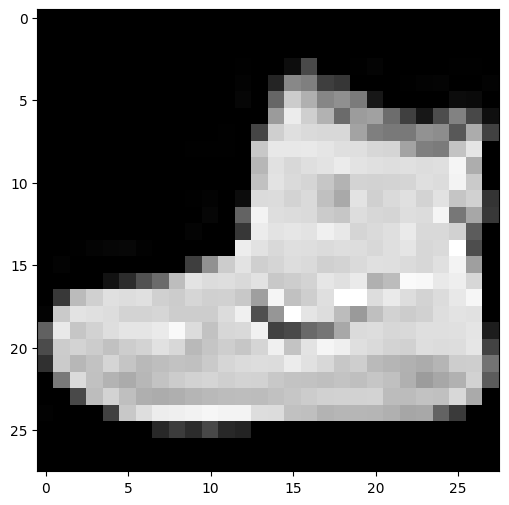

In [3]:
plt.figure(figsize=(10,6))
plt.imshow(train_values[0], cmap='gray')

plt.show()

In [4]:
T = 200  # Total simulation time
dt = 0.2  # Simulation time step
nt = round(T / dt)  # Total simulation steps
time = np.linspace(0, T, nt)

In [5]:
output_signals = []

for i in range(10):
    signal = np.zeros((nt, 10))
    signal[:, i] = 1
    output_signals.append(signal)

In [6]:
output_signals_tensor = torch.stack([torch.tensor(signal, dtype=torch.float32) for signal in output_signals])

print(train_values_tensor.shape)
print(train_labels_tensor.shape)
print(test_values_tensor.shape)
print(test_labels_tensor.shape)
print(output_signals_tensor.shape)

torch.Size([60000, 28, 28])
torch.Size([60000])
torch.Size([10000, 28, 28])
torch.Size([10000])
torch.Size([10, 1000, 10])


In [7]:
batch_size = 200
train_dataloader = DataLoader(TensorDataset(train_values_tensor, train_labels_tensor), batch_size=batch_size, shuffle=True)
test_dataloader = DataLoader(TensorDataset(test_values_tensor, test_labels_tensor), batch_size=batch_size, shuffle=True)

In [8]:
train_values_tensor = train_values_tensor.to(device)
train_labels_tensor = train_labels_tensor.to(device)
output_signals_tensor = output_signals_tensor.to(device)

## ML-SNN Model

In [ ]:
@torch.jit.script
def compute_output(s_e: torch.Tensor, s_i: torch.Tensor, weight: torch.Tensor, bias: torch.Tensor) -> torch.Tensor:
    cat = torch.cat([s_e, s_i], 1)
    return F.linear(cat, weight, bias)

@torch.jit.script
def compute_derivatives(
    V_e: torch.Tensor, n_e: torch.Tensor, s_e: torch.Tensor,
    V_i: torch.Tensor, n_i: torch.Tensor, s_i: torch.Tensor,
    I_e: torch.Tensor, I_i: torch.Tensor,
    omega_ee: torch.Tensor, omega_ei: torch.Tensor, 
    omega_ie: torch.Tensor, omega_ii: torch.Tensor,
    V1: float, V2: float, V3: float, V4: float,
    T_max: float, V_t: float, K_p: float,
    g_Ca: float, V_Ca: float, g_K: float, V_K: float, g_L: float, V_L: float,
    phi: float, ar_e: float, ad_e: float, ar_i: float, ad_i: float,
    gbar_e: float, gbar_i: float, E_ampa: float, E_gaba: float,
    Cm: float
) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor]:
    m_inf_e = 0.5 * (1 + torch.tanh((V_e - V1) / V2))
    n_inf_e = 0.5 * (1 + torch.tanh((V_e - V3) / V4))
    # tau_n_e = 1.0 / torch.cosh((V_e - V3) / (2 * V4))
    tau_n_e = 1.0
    TM_e = T_max / (1 + torch.exp(-(V_e - V_t) / K_p))
    
    m_inf_i = 0.5 * (1 + torch.tanh((V_i - V1) / V2))
    n_inf_i = 0.5 * (1 + torch.tanh((V_i - V3) / V4))
    # tau_n_i = 1.0 / torch.cosh((V_i - V3) / (2 * V4))
    tau_n_i = 1.0
    TM_i = T_max / (1 + torch.exp(-(V_i - V_t) / K_p))
    
    I_syn_e = (gbar_e * torch.mm(s_e, omega_ee.transpose(0,1)) * (V_e - E_ampa) +
               gbar_i * torch.mm(s_i, omega_ei.transpose(0,1)) * (V_e - E_gaba))
    I_syn_i = (gbar_e * torch.mm(s_e, omega_ie.transpose(0,1)) * (V_i - E_ampa) +
               gbar_i * torch.mm(s_i, omega_ii.transpose(0,1)) * (V_i - E_gaba))
    
    dV_e = (I_e - g_L*(V_e - V_L) - g_K*n_e*(V_e - V_K) - g_Ca*m_inf_e*(V_e - V_Ca) - I_syn_e) / Cm
    dn_e = phi*(n_inf_e - n_e) / tau_n_e
    ds_e = ar_e * TM_e * (1.0 - s_e) - ad_e * s_e
    
    dV_i = (I_i - g_L*(V_i - V_L) - g_K*n_i*(V_i - V_K) - g_Ca*m_inf_i*(V_i - V_Ca) - I_syn_i) / Cm
    dn_i = phi*(n_inf_i - n_i) / tau_n_i
    ds_i = ar_i * TM_i * (1.0 - s_i) - ad_i * s_i
    
    return dV_e, dn_e, ds_e, dV_i, dn_i, ds_i

@torch.jit.script
def rk4_step(
    V_e: torch.Tensor, n_e: torch.Tensor, s_e: torch.Tensor,
    V_i: torch.Tensor, n_i: torch.Tensor, s_i: torch.Tensor,
    I_e: torch.Tensor, I_i: torch.Tensor, dt: float,
    omega_ee: torch.Tensor, omega_ei: torch.Tensor, 
    omega_ie: torch.Tensor, omega_ii: torch.Tensor,
    V1: float, V2: float, V3: float, V4: float,
    T_max: float, V_t: float, K_p: float,
    g_Ca: float, V_Ca: float, g_K: float, V_K: float, g_L: float, V_L: float,
    phi: float, ar_e: float, ad_e: float, ar_i: float, ad_i: float,
    gbar_e: float, gbar_i: float, E_ampa: float, E_gaba: float,
    Cm: float
) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor]:
    k1 = compute_derivatives(V_e, n_e, s_e, V_i, n_i, s_i, I_e, I_i,
                             omega_ee, omega_ei, omega_ie, omega_ii,
                             V1, V2, V3, V4, T_max, V_t, K_p,
                             g_Ca, V_Ca, g_K, V_K, g_L, V_L,
                             phi, ar_e, ad_e, ar_i, ad_i,
                             gbar_e, gbar_i, E_ampa, E_gaba, Cm)
    V_e_k2 = V_e + 0.5 * dt * k1[0]
    n_e_k2 = n_e + 0.5 * dt * k1[1]
    s_e_k2 = s_e + 0.5 * dt * k1[2]
    V_i_k2 = V_i + 0.5 * dt * k1[3]
    n_i_k2 = n_i + 0.5 * dt * k1[4]
    s_i_k2 = s_i + 0.5 * dt * k1[5]
    k2 = compute_derivatives(V_e_k2, n_e_k2, s_e_k2, V_i_k2, n_i_k2, s_i_k2, I_e, I_i,
                             omega_ee, omega_ei, omega_ie, omega_ii,
                             V1, V2, V3, V4, T_max, V_t, K_p,
                             g_Ca, V_Ca, g_K, V_K, g_L, V_L,
                             phi, ar_e, ad_e, ar_i, ad_i,
                             gbar_e, gbar_i, E_ampa, E_gaba, Cm)
    V_e_k3 = V_e + 0.5 * dt * k2[0]
    n_e_k3 = n_e + 0.5 * dt * k2[1]
    s_e_k3 = s_e + 0.5 * dt * k2[2]
    V_i_k3 = V_i + 0.5 * dt * k2[3]
    n_i_k3 = n_i + 0.5 * dt * k2[4]
    s_i_k3 = s_i + 0.5 * dt * k2[5]
    k3 = compute_derivatives(V_e_k3, n_e_k3, s_e_k3, V_i_k3, n_i_k3, s_i_k3, I_e, I_i,
                             omega_ee, omega_ei, omega_ie, omega_ii,
                             V1, V2, V3, V4, T_max, V_t, K_p,
                             g_Ca, V_Ca, g_K, V_K, g_L, V_L,
                             phi, ar_e, ad_e, ar_i, ad_i,
                             gbar_e, gbar_i, E_ampa, E_gaba, Cm)
    V_e_k4 = V_e + dt * k3[0]
    n_e_k4 = n_e + dt * k3[1]
    s_e_k4 = s_e + dt * k3[2]
    V_i_k4 = V_i + dt * k3[3]
    n_i_k4 = n_i + dt * k3[4]
    s_i_k4 = s_i + dt * k3[5]
    k4 = compute_derivatives(V_e_k4, n_e_k4, s_e_k4, V_i_k4, n_i_k4, s_i_k4, I_e, I_i,
                             omega_ee, omega_ei, omega_ie, omega_ii,
                             V1, V2, V3, V4, T_max, V_t, K_p,
                             g_Ca, V_Ca, g_K, V_K, g_L, V_L,
                             phi, ar_e, ad_e, ar_i, ad_i,
                             gbar_e, gbar_i, E_ampa, E_gaba, Cm)
    V_e_new = V_e + (dt/6.0) * (k1[0] + 2*k2[0] + 2*k3[0] + k4[0])
    n_e_new = n_e + (dt/6.0) * (k1[1] + 2*k2[1] + 2*k3[1] + k4[1])
    s_e_new = s_e + (dt/6.0) * (k1[2] + 2*k2[2] + 2*k3[2] + k4[2])
    V_i_new = V_i + (dt/6.0) * (k1[3] + 2*k2[3] + 2*k3[3] + k4[3])
    n_i_new = n_i + (dt/6.0) * (k1[4] + 2*k2[4] + 2*k3[4] + k4[4])
    s_i_new = s_i + (dt/6.0) * (k1[5] + 2*k2[5] + 2*k3[5] + k4[5])
    return V_e_new, n_e_new, s_e_new, V_i_new, n_i_new, s_i_new


@torch.jit.script
def integrate_chunk_with_output(
    input: torch.Tensor,
    chunk_size: int,
    init_V_e: torch.Tensor, init_n_e: torch.Tensor, init_s_e: torch.Tensor,
    init_V_i: torch.Tensor, init_n_i: torch.Tensor, init_s_i: torch.Tensor,
    dt: float, I: float,  
    omega_ee: torch.Tensor, omega_ei: torch.Tensor, 
    omega_ie: torch.Tensor, omega_ii: torch.Tensor,
    V1: float, V2: float, V3: float, V4: float,
    T_max: float, V_t: float, K_p: float,
    g_Ca: float, V_Ca: float, g_K: float, V_K: float, g_L: float, V_L: float,
    phi: float, ar_e: float, ad_e: float, ar_i: float, ad_i: float,
    gbar_e: float, gbar_i: float, E_ampa: float, E_gaba: float,
    Cm: float,
    proj_weight: torch.Tensor, proj_bias: torch.Tensor,
    out_weight: torch.Tensor, out_bias: torch.Tensor
) -> Tuple[torch.Tensor,
           Tuple[torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor],
           Tuple[torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor]]:

    steps = chunk_size
    batch_size = input.size(0)
    
    V_e, n_e, s_e = init_V_e, init_n_e, init_s_e
    V_i, n_i, s_i = init_V_i, init_n_i, init_s_i

    outputs = []
    
    V_e_list = torch.jit.annotate(List[torch.Tensor], [])
    n_e_list = torch.jit.annotate(List[torch.Tensor], [])
    s_e_list = torch.jit.annotate(List[torch.Tensor], [])
    V_i_list = torch.jit.annotate(List[torch.Tensor], [])
    n_i_list = torch.jit.annotate(List[torch.Tensor], [])
    s_i_list = torch.jit.annotate(List[torch.Tensor], [])

    projected_input = F.linear(input * 40.0, proj_weight, proj_bias) + I
    
    # Split into excitatory and inhibitory drive:
    NE = V_e.size(1)
    I_e = projected_input[:, :NE]
    I_i = projected_input[:, NE:]
    
    for t in range(steps):       
        V_e, n_e, s_e, V_i, n_i, s_i = rk4_step(
            V_e, n_e, s_e, V_i, n_i, s_i, I_e, I_i, dt,
            omega_ee, omega_ei, omega_ie, omega_ii,
            V1, V2, V3, V4, T_max, V_t, K_p,
            g_Ca, V_Ca, g_K, V_K, g_L, V_L,
            phi, ar_e, ad_e, ar_i, ad_i,
            gbar_e, gbar_i, E_ampa, E_gaba, Cm
        )
        out = compute_output(s_e, s_i, out_weight, out_bias)
        outputs.append(out)
        
        V_e_list.append(V_e[0].clone())
        n_e_list.append(n_e[0].clone())
        s_e_list.append(s_e[0].clone())
        V_i_list.append(V_i[0].clone())
        n_i_list.append(n_i[0].clone())
        s_i_list.append(s_i[0].clone())

    outputs_tensor = torch.stack(outputs, dim=0)
    final_states = (V_e, n_e, s_e, V_i, n_i, s_i)
    all_states = (torch.stack(V_e_list, dim=0),
                  torch.stack(n_e_list, dim=0),
                  torch.stack(s_e_list, dim=0),
                  torch.stack(V_i_list, dim=0),
                  torch.stack(n_i_list, dim=0),
                  torch.stack(s_i_list, dim=0))
    return outputs_tensor, final_states, all_states

# --------------------------------------------------------------------
# Morris-Lecar SNN Model
# --------------------------------------------------------------------
class MorrisLecarSNN(nn.Module):
    def __init__(self, input_size, output_size, chunk_size, NE=250, NI=250, dt=0.1,
                 Cm=20.0, g_Ca=4.0, g_K=8.0, g_L=2.0, V_Ca=120.0, V_K=-84.0, V_L=-60.0,
                 phi=0.067, V1=-1.2, V2=18.0, V3=12.0, V4=17.4, ar_e=3.0, ad_e=0.1,
                 ar_i=3.0, ad_i=0.1, T_max=1.0, V_t=2.0, K_p=5.0, gbar_e=1.0, gbar_i=1.0,
                 E_ampa=0.0, E_gaba=-75.0, I= 70.0):
        super(MorrisLecarSNN, self).__init__()
        self.NE = NE
        self.NI = NI
        self.dt = dt
        self.hidden_size = NE + NI
        self.chunk_size = chunk_size

        # Model parameters
        self.I = I
        self.Cm = Cm
        self.g_Ca = g_Ca
        self.g_K = g_K
        self.g_L = g_L
        self.V_Ca = V_Ca
        self.V_K = V_K
        self.V_L = V_L
        self.phi = phi
        self.V1 = V1
        self.V2 = V2
        self.V3 = V3
        self.V4 = V4
        self.ar_e = ar_e
        self.ad_e = ad_e
        self.ar_i = ar_i
        self.ad_i = ad_i
        self.T_max = T_max
        self.V_t = V_t
        self.K_p = K_p
        self.gbar_e = gbar_e
        self.gbar_i = gbar_i
        self.E_ampa = E_ampa
        self.E_gaba = E_gaba

        # Input layer
        self.input_projection = nn.Linear(input_size, self.hidden_size)
        
        # Synaptic weights
        self.omega_ee_raw = nn.Parameter(torch.randn(NE, NE, device=device))
        self.omega_ei_raw = nn.Parameter(torch.randn(NE, NE, device=device))
        self.omega_ie_raw = nn.Parameter(torch.randn(NE, NE, device=device))
        self.omega_ii_raw = nn.Parameter(torch.randn(NE, NE, device=device))
        
        # Upper bound
        self.upper_bound = 1 / math.sqrt(self.hidden_size)

        # Output layer
        self.output_layer = nn.Linear(self.hidden_size, output_size)

        # State storage (if needed)
        self.store_states = False
        self._storage = None
        self._storage_idx = 0
    
    # Property to get bounded omega matrices
    @property
    def omega_ee(self):
        return torch.sigmoid(self.omega_ee_raw) * self.upper_bound
    
    @property
    def omega_ei(self):
        return torch.sigmoid(self.omega_ei_raw) * self.upper_bound
    
    @property
    def omega_ie(self):
        return torch.sigmoid(self.omega_ie_raw) * self.upper_bound
    
    @property
    def omega_ii(self):
        return torch.sigmoid(self.omega_ii_raw) * self.upper_bound
    
    def _init_storage(self, total_steps: int):
        device = self.input_projection.weight.device
        self._storage = {
            'V_e': torch.zeros(total_steps, self.NE, device=device),
            'n_e': torch.zeros(total_steps, self.NE, device=device),
            's_e': torch.zeros(total_steps, self.NE, device=device),
            'V_i': torch.zeros(total_steps, self.NI, device=device),
            'n_i': torch.zeros(total_steps, self.NI, device=device),
            's_i': torch.zeros(total_steps, self.NI, device=device)
        }
        self._storage_idx = 0

    def enable_storage(self, total_steps: int):
        self.store_states = True
        self._init_storage(total_steps)

    def disable_storage(self):
        self.store_states = False
        self._storage = None
        self._storage_idx = 0

    def get_storage(self):
        return self._storage

    def _init_states(self, batch_size: int):
        device = self.input_projection.weight.device
        V_e = 30 * torch.rand((batch_size, self.NE), device=device)
        n_e = torch.rand((batch_size, self.NE), device=device)
        s_e = torch.zeros((batch_size, self.NE), device=device)
        V_i = -50 + 30 * torch.rand((batch_size, self.NI), device=device)
        n_i = torch.rand((batch_size, self.NI), device=device)
        s_i = torch.zeros((batch_size, self.NI), device=device)
        return (V_e, n_e, s_e, V_i, n_i, s_i)

    def forward(self, input, states=None):
        """
        x_sequence: [batch_size, seq_len, input_size]
        For each time step, we require the output.
        We process the sequence in chunks using our scripted integration function.
        """
        batch_size, _ = input.shape
        outputs_list = []

        if states is None:
            states = self._init_states(batch_size)
        
        # We need to get the projection and output layer parameters.
        proj_weight = self.input_projection.weight
        proj_bias = self.input_projection.bias
        out_weight = self.output_layer.weight
        out_bias = self.output_layer.bias

        # Call the scripted integration function that returns outputs for each step in the chunk.
        chunk_outputs, states, all_states = integrate_chunk_with_output(
            input, self.chunk_size, states[0], states[1], states[2],
            states[3], states[4], states[5],
            self.dt, self.I,
            self.omega_ee, self.omega_ei, self.omega_ie, self.omega_ii,
            self.V1, self.V2, self.V3, self.V4,
            self.T_max, self.V_t, self.K_p,
            self.g_Ca, self.V_Ca, self.g_K, self.V_K, self.g_L, self.V_L,
            self.phi, self.ar_e, self.ad_e, self.ar_i, self.ad_i,
            self.gbar_e, self.gbar_i, self.E_ampa, self.E_gaba,
            self.Cm,
            proj_weight, proj_bias,
            out_weight, out_bias
        )
       
        # chunk_outputs is [chunk_len, batch_size, output_size]; transpose it to [batch_size, chunk_len, output_size]
        chunk_outputs = chunk_outputs.transpose(0, 1)
        outputs_list.append(chunk_outputs)
        if self.store_states:
            steps = self.chunk_size
            with torch.no_grad():
                self._storage['V_e'][self._storage_idx:self._storage_idx + steps] = all_states[0]
                self._storage['n_e'][self._storage_idx:self._storage_idx + steps] = all_states[1]
                self._storage['s_e'][self._storage_idx:self._storage_idx + steps] = all_states[2]
                self._storage['V_i'][self._storage_idx:self._storage_idx + steps] = all_states[3]
                self._storage['n_i'][self._storage_idx:self._storage_idx + steps] = all_states[4]
                self._storage['s_i'][self._storage_idx:self._storage_idx + steps] = all_states[5]
                self._storage_idx += steps
        # Concatenate outputs along the time dimension.
        outputs = torch.cat(outputs_list, dim=1)  # shape: [batch_size, seq_len, output_size]
        return outputs, states

    def warmup(self, input, states=None):
        """
        x_sequence: [batch_size, seq_len, input_size]
        For each time step, we require the output.
        We process the sequence in chunks using our scripted integration function.
        """
        with torch.no_grad():
            batch_size, _ = input.shape
            outputs_list = []
    
            if states is None:
                states = self._init_states(batch_size)
            
            # We need to get the projection and output layer parameters.
            proj_weight = self.input_projection.weight
            proj_bias = self.input_projection.bias
            out_weight = self.output_layer.weight
            out_bias = self.output_layer.bias

            # Call the scripted integration function that returns outputs for each step in the chunk.
            _, states, _ = integrate_chunk_with_output(
                input, self.chunk_size, states[0], states[1], states[2],
                states[3], states[4], states[5],
                self.dt, self.I,
                self.omega_ee, self.omega_ei, self.omega_ie, self.omega_ii,
                self.V1, self.V2, self.V3, self.V4,
                self.T_max, self.V_t, self.K_p,
                self.g_Ca, self.V_Ca, self.g_K, self.V_K, self.g_L, self.V_L,
                self.phi, self.ar_e, self.ad_e, self.ar_i, self.ad_i,
                self.gbar_e, self.gbar_i, self.E_ampa, self.E_gaba,
                self.Cm,
                proj_weight, proj_bias,
                out_weight, out_bias
            )
           
        return states


    def plot_full_state(self, num_neurons=5, neuron_offset=2.0, figure_name=""):
        if not self.store_states or self._storage is None:
            print("Storage not enabled or no data stored!")
            return
        
        store = {k: v.cpu().numpy() for k, v in self._storage.items()}
        time_steps = store['V_e'].shape[0]
        time = np.arange(0, time_steps) * self.dt

        fig = plt.figure(figsize=(18, 12))
        plt.suptitle("Neuronal State Dynamics (T=100s)", fontsize=16)
        gs = fig.add_gridspec(3, 2)
        axs = {
            'V_e': fig.add_subplot(gs[0, 0]),
            'V_i': fig.add_subplot(gs[0, 1]),
            'n_e': fig.add_subplot(gs[1, 0]),
            'n_i': fig.add_subplot(gs[1, 1]),
            's_e': fig.add_subplot(gs[2, 0]),
            's_i': fig.add_subplot(gs[2, 1])
        }

        rand_e = np.random.choice(self.NE, num_neurons, replace=False)
        rand_i = np.random.choice(self.NI, num_neurons, replace=False)

        for idx, n in enumerate(rand_e):
            offset = idx * neuron_offset
            axs['V_e'].plot(time, (store['V_e'][:, n]) / 150 + offset, label=f'Neuron {n}')
            axs['n_e'].plot(time, store['n_e'][:, n] + offset)
            axs['s_e'].plot(time, store['s_e'][:, n] + offset)

        for idx, n in enumerate(rand_i):
            offset = idx * neuron_offset
            axs['V_i'].plot(time, (store['V_i'][:, n]) / 150 + offset, label=f'Neuron {n}')
            axs['n_i'].plot(time, store['n_i'][:, n] + offset)
            axs['s_i'].plot(time, store['s_i'][:, n] + offset)

        titles = {
            'V_e': "Excitatory Membrane Potentials",
            'V_i': "Inhibitory Membrane Potentials",
            'n_e': "Excitatory Gating Variables",
            'n_i': "Inhibitory Gating Variables",
            's_e': "Excitatory Synaptic Variables",
            's_i': "Inhibitory Synaptic Variables"
        }
        for key, ax in axs.items():
            ax.set_title(titles[key])
            ax.set_xlabel("Time (s)")
            ax.grid(True, alpha=0.3)
            if key in ['V_e', 'V_i']:
                ax.legend()

        plt.tight_layout(rect=[0, 0, 1, 0.95])
        if figure_name:
            plt.savefig(figure_name, bbox_inches='tight')
        plt.show()

## Initialize the model and training parameters

In [11]:
np.random.seed(42)
torch.manual_seed(42)

chunk_size = 100
epochs = 5
states = None

model = MorrisLecarSNN(input_size=28*28, output_size=10, chunk_size=chunk_size, NE=500, NI=500, dt=dt).to(device)

optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-4)

criterion = nn.CrossEntropyLoss()

initial_state_path = 'Fashion-MNIST-initial.pth'
final_state_path = 'Fashion-MNIST-final.pth'

torch.save(model.state_dict(), initial_state_path)
print(f"Initial model state saved to {initial_state_path}")

Initial model state saved to Fashion-MNIST-initial.pth


## Training

In [ ]:
%%time

progress_interval = 0.04

np.random.seed(42)
torch.manual_seed(42)

warmup_duration = 200
epoch_has_nan = False 
for epoch in range(epochs):
    model.train()
    loss = 0
    total_right = 0
    batch_right = 0
    total_loss = 0
    batch_loss = 0

    num_batches = len(train_dataloader)
    progress_step = int(progress_interval * num_batches)  # Number of batches per progress print

    for batch_idx, (images, labels) in enumerate(train_dataloader):
        # Preprocess inputs and targets
        input_seq = images.view(batch_size, 28*28).to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        states = None  # Reset recurrent states at the beginning of the batch
        outputs_list = [] 
        
        with torch.no_grad():
            states = model.warmup(torch.zeros(batch_size, 28*28).to(device), states)        

        # Process the sequence in TBPTT chunks
        for start in range(0, nt, chunk_size):
            
            chunk_outputs, states = model(input_seq, states)
            avg_outputs = torch.mean(chunk_outputs, dim=1)  
            loss = criterion(avg_outputs, labels.long())

            loss.backward()
            batch_loss += loss.detach().item()
            total_loss += loss.detach().item()
            outputs_list.append(chunk_outputs.detach())

            if states is not None:
                states = tuple(s.detach() for s in states)

        optimizer.step()

        outputs = torch.cat(outputs_list, dim=1)
        avg_outputs = torch.mean(outputs, dim=1)  # Average over time: [batch_size, 10]
        predictions = torch.argmax(avg_outputs, dim=1)

        correct_predictions = (predictions == labels).sum().item()

        batch_right += correct_predictions
        total_right += correct_predictions

        if (batch_idx + 1) % progress_step == 0 or (batch_idx + 1) == num_batches:
            print(f"Epoch: {epoch+1}/{epochs}, "
                  f"Progress: {100 * (batch_idx + 1) / num_batches:.2f}%, "
                  f"BatchLoss: {batch_loss:.4f}, "
        
            f"BatchAccuracy: {batch_right / (batch_size * num_batches * progress_interval):.4f}, "
                  f"TotalAccuracy: {total_right / len(train_dataloader.dataset):.4f}")
            batch_loss = 0
            batch_right = 0
    
    print(f"Epoch: {epoch+1}, TotalLoss: {total_loss:.4f}, "
          f"Accuracy: {total_right / len(train_dataloader.dataset):.4f}")
    
checkpoint = {
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict()
}

torch.save(checkpoint, final_state_path)
print("Model and optimizer state saved successfully!")

Epoch: 1/5, Progress: 4.00%, BatchLoss: 172.3266, BatchAccuracy: 0.5787, TotalAccuracy: 0.0232
Epoch: 1/5, Progress: 8.00%, BatchLoss: 98.5328, BatchAccuracy: 0.7267, TotalAccuracy: 0.0522
Epoch: 1/5, Progress: 12.00%, BatchLoss: 80.8008, BatchAccuracy: 0.7521, TotalAccuracy: 0.0823
Epoch: 1/5, Progress: 16.00%, BatchLoss: 77.7472, BatchAccuracy: 0.7567, TotalAccuracy: 0.1126
Epoch: 1/5, Progress: 20.00%, BatchLoss: 70.4271, BatchAccuracy: 0.7925, TotalAccuracy: 0.1443
Epoch: 1/5, Progress: 24.00%, BatchLoss: 66.1658, BatchAccuracy: 0.8075, TotalAccuracy: 0.1766
Epoch: 1/5, Progress: 28.00%, BatchLoss: 67.8531, BatchAccuracy: 0.8017, TotalAccuracy: 0.2086
Epoch: 1/5, Progress: 32.00%, BatchLoss: 68.8753, BatchAccuracy: 0.7937, TotalAccuracy: 0.2404
Epoch: 1/5, Progress: 36.00%, BatchLoss: 60.1608, BatchAccuracy: 0.8267, TotalAccuracy: 0.2735
Epoch: 1/5, Progress: 40.00%, BatchLoss: 60.8605, BatchAccuracy: 0.8146, TotalAccuracy: 0.3060
Epoch: 1/5, Progress: 44.00%, BatchLoss: 62.1761, B

In [13]:
checkpoint = torch.load(final_state_path, map_location=device)

model = MorrisLecarSNN(input_size=28*28, output_size=10, chunk_size=chunk_size, NE=500, NI=500, dt=dt).to(device)

model.load_state_dict(checkpoint['model_state_dict'])

<All keys matched successfully>

## Testing

In [ ]:
model.eval()

# Disable gradient computation for efficiency
total_loss = 0
total_correct = 0
num_samples = 0
warmup_duration = 200
model.disable_storage()
model.enable_storage(total_steps=nt)  # Pre-allocate for 1000 timesteps
all_labels = []
all_predictions = []
with torch.no_grad():
    for images, labels in test_dataloader:
        # Prepare input sequences
        input = images.view(batch_size, 28*28).to(device)
        labels = labels.to(device)

        states = None  # Reset recurrent states
        outputs_list = []
        model._storage_idx = 0  # Reset storage index for this batch

        
        with torch.no_grad():
            states = model.warmup(torch.zeros(batch_size, 28*28).to(device), states)   

        # Process the sequence in chunks (Truncated Backpropagation Through Time)
        for start in range(0, nt, chunk_size):

            # Forward pass
            chunk_outputs, states = model(input, states)
            avg_outputs = torch.mean(chunk_outputs, dim=1)  # Average over time: [batch_size, 10]
            total_loss = criterion(avg_outputs, labels.long()).item()

            outputs_list.append(chunk_outputs)

            # Detach states to prevent expanding the computation graph
            if states is not None:
                states = tuple(s.detach() for s in states)

        # Concatenate outputs over all chunks
        outputs = torch.cat(outputs_list, dim=1)
        avg_outputs = torch.mean(outputs, dim=1)  # Average over time
        predictions = torch.argmax(avg_outputs, dim=1)

        # Compute accuracy
        total_correct += (predictions == labels).sum().item()
        num_samples += labels.size(0)
        all_labels.extend(labels.cpu().numpy())
        all_predictions.extend(predictions.cpu().numpy())


# Compute final metrics
avg_loss = total_loss / len(test_dataloader)
accuracy = total_correct / num_samples

print(f"Test Loss: {avg_loss:.4f}, Test Accuracy: {accuracy:.4f}")
data = model.get_storage()

Test Loss: 0.0047, Test Accuracy: 0.8741


In [15]:
from sklearn.metrics import confusion_matrix, classification_report
all_labels = np.array(all_labels)
all_predictions = np.array(all_predictions)

# Generate the confusion matrix
conf_matrix = confusion_matrix(all_labels, all_predictions)

print("\nConfusion Matrix:")
print(conf_matrix)

# Optional: Calculate overall accuracy from the confusion matrix
overall_accuracy = np.sum(np.diag(conf_matrix)) / np.sum(conf_matrix)
print(f"\nOverall Test Accuracy (from Confusion Matrix): {overall_accuracy:.4f}")
class_names = [str(i) for i in range(10)] # Assuming 10 classes (0-9)

print("\nClassification Report:")
print(classification_report(all_labels, all_predictions, target_names=class_names))



Confusion Matrix:
[[782   0  11  36   5   2 152   1  11   0]
 [  3 963   2  24   3   0   4   0   1   0]
 [ 14   0 753  15 117   1  96   0   4   0]
 [ 17   3   6 902  37   0  31   0   4   0]
 [  0   1  64  30 823   0  78   0   4   0]
 [  0   0   0   1   0 948   0  36   2  13]
 [ 95   1  72  34  63   0 717   0  18   0]
 [  0   0   0   0   0  23   0 966   0  11]
 [  4   1   1   4   2   4   8   5 971   0]
 [  1   0   0   0   0  16   0  67   0 916]]

Overall Test Accuracy (from Confusion Matrix): 0.8741

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.78      0.82      1000
           1       0.99      0.96      0.98      1000
           2       0.83      0.75      0.79      1000
           3       0.86      0.90      0.88      1000
           4       0.78      0.82      0.80      1000
           5       0.95      0.95      0.95      1000
           6       0.66      0.72      0.69      1000
           7       0.90      0.97     

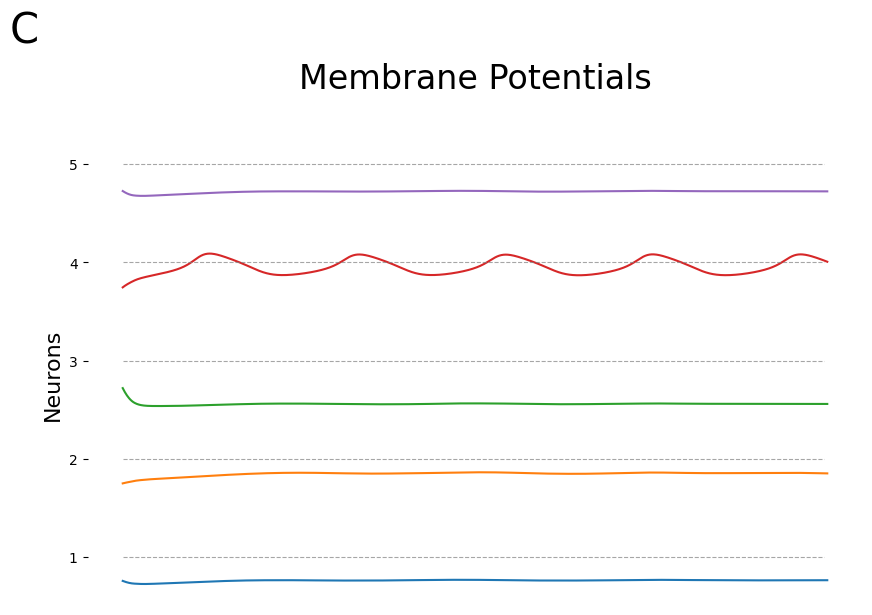

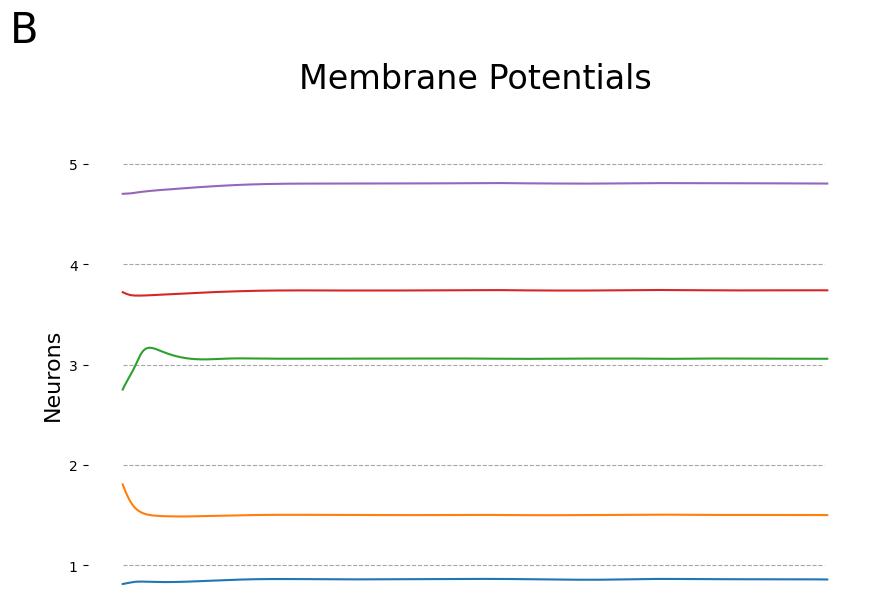

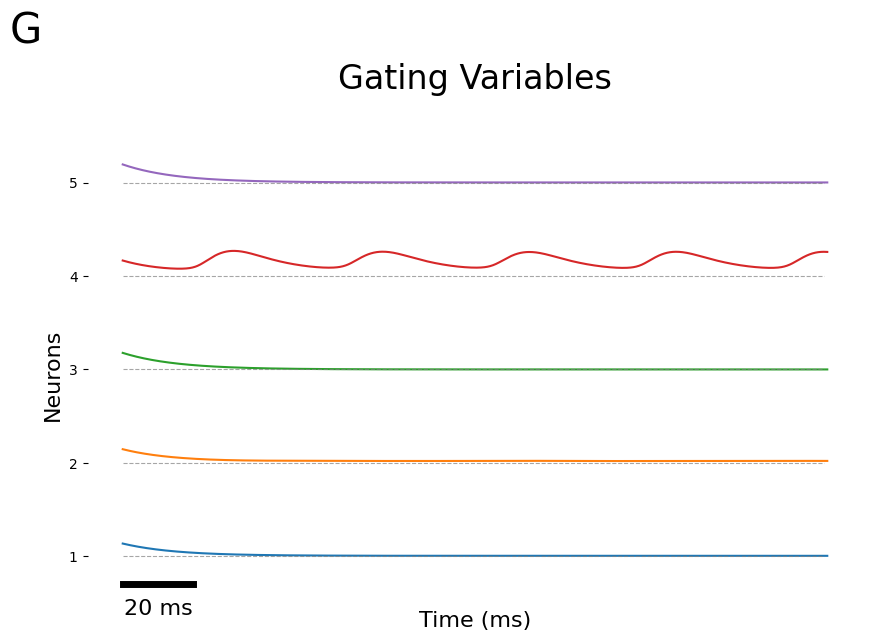

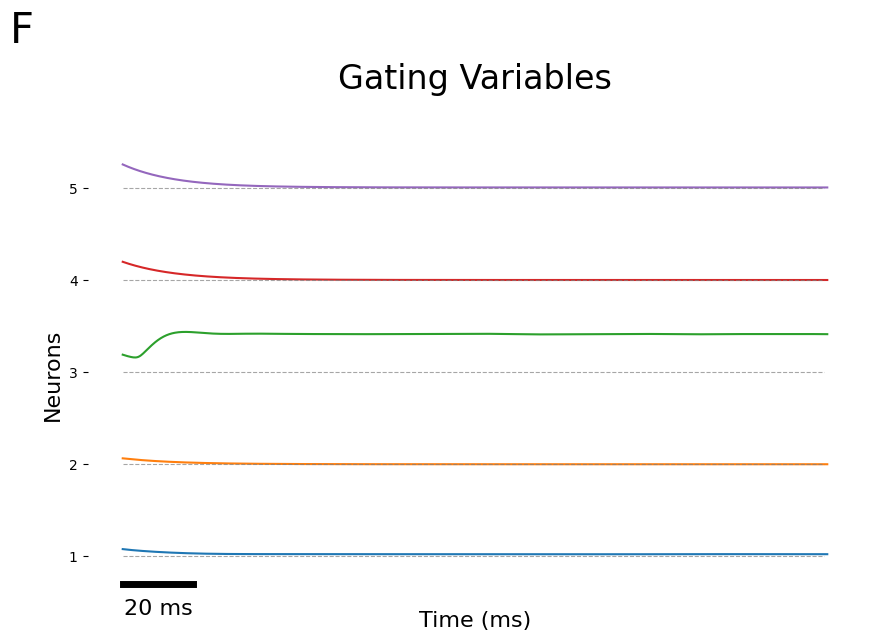

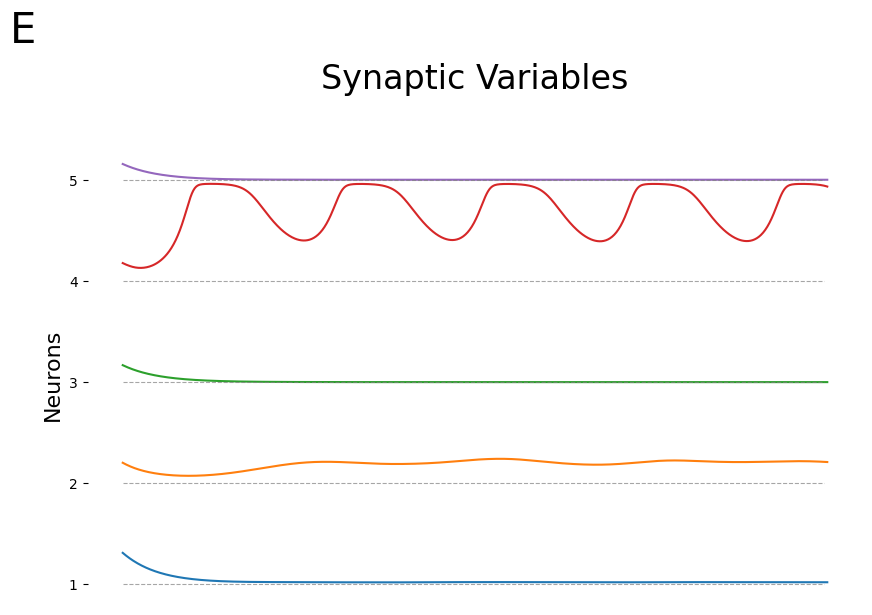

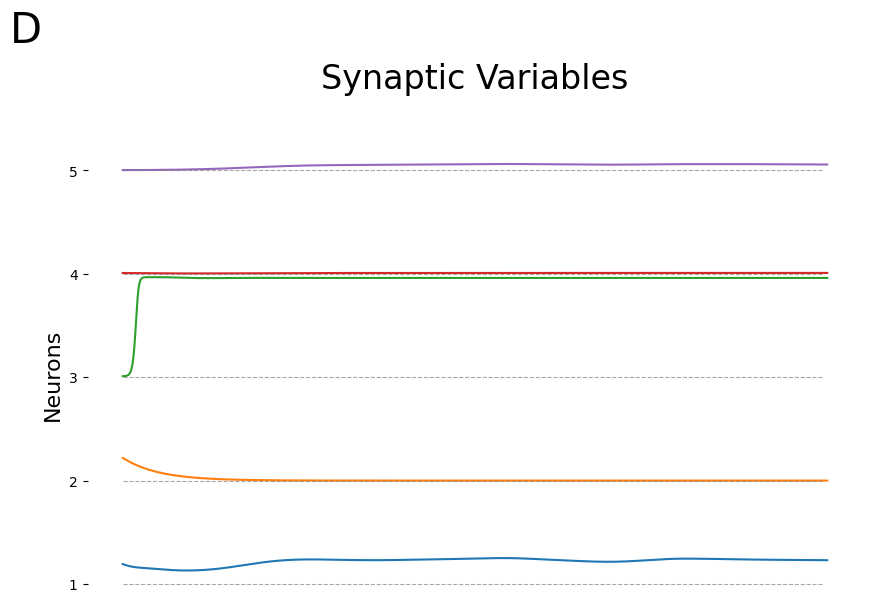

In [ ]:
def savePlot_full_state(data, num_neurons=5, neuron_offset=1.0, figure_name_prefix="", linewidth=1.5):
    # Convert data to numpy arrays directly from CPU tensors
    store = {k: v.cpu().numpy() for k, v in data.items()}
    time_steps = store['V_e'].shape[0]  # Changed from len() to shape[0]
    time = np.arange(0, time_steps) * dt
    
    # Plot settings remain mostly the same
    plot_configs = {
        'V_e': ("Membrane Potentials", "C", store['V_e'], 0, lambda x: (x)/150),
        'V_i': ("Membrane Potentials", "B", store['V_i'], 0, lambda x: (x)/150),
        'n_e': ("Gating Variables", "G", store['n_e'], 0, lambda x: x),
        'n_i': ("Gating Variables", "F", store['n_i'], 0, lambda x: x),
        's_e': ("Synaptic Variables", "E", store['s_e'], 0, lambda x: x),
        's_i': ("Synaptic Variables", "D", store['s_i'], 0, lambda x: x)
    }
    
    # Assuming NE and NI are defined somewhere, or use fixed values like original
    rand_e = np.random.choice(250, num_neurons, False)
    # rand_e = [243]
    rand_i = np.random.choice(250, num_neurons, False)
    
    # Create and save individual plots
    for plot_key, (title, order, data, dim, transform) in plot_configs.items():
        fig = plt.figure(figsize=(10, 6))
        ax = fig.add_subplot(111)
        
        # Plot either excitatory or inhibitory neurons based on key
        if 'e' in plot_key:
            neurons = rand_e
            neuron_type = 'Excitatory'
        else:
            neurons = rand_i
            neuron_type = 'Inhibitory'
            
        for idx, n in enumerate(neurons):
            offset = idx * neuron_offset
            # Plot the neuron activity trace using the same data access pattern
            ax.plot(time, transform(data[:, n]) + offset,
                   linewidth=linewidth, label=f'{neurons[idx]}')
            # Plot the baseline
            x = np.arange(0, 200)
            y = np.full_like(x, offset)
            ax.plot(x, y, color='gray', linestyle='--', linewidth=0.8, alpha=0.7)
    
        # Rest of the plotting configuration remains the same
        plt.gca().spines['bottom'].set_visible(False)
        plt.gca().spines['left'].set_visible(False)
        plt.gca().spines['right'].set_visible(False)
        plt.gca().spines['top'].set_visible(False)
        
        ax.set_title(title, fontsize=24, y=1.1)
        plt.title(order, fontsize=30, loc='left', y=1.2, x=-0.1)
        # plt.legend()
        if title == "Gating Variables":
            ax.set_xlabel("Time (ms)", fontsize=16)
            x_start = 0
            x_end = 20  # 20 ms
            y_pos = plt.ylim()[0] - 0.02 * (plt.ylim()[1] - plt.ylim()[0])  # Position slightly below the plot
            
            plt.plot([x_start, x_end], [y_pos, y_pos], color='black', linewidth=5)
            plt.text((x_start + x_end) / 2, y_pos - 0.03 * (plt.ylim()[1] - plt.ylim()[0]), "20 ms", 
     ha='center', va='top', fontsize=16)
        # ax.grid(True, alpha=0.3)
        ax.set_yticks(np.arange(0, num_neurons) * neuron_offset)
        ax.set_yticklabels([str(i+1) for i in range(num_neurons)]) # This should not have hyphens.
        ax.set_ylabel("Neurons", fontsize=16)
        ax.set_xticks([])
    
        # Save the figure
        if figure_name_prefix:
            filename = f"{figure_name_prefix}_{plot_key}.svg"
            plt.savefig(filename, format='svg', bbox_inches='tight', dpi=300)
            plt.show()
        plt.close(fig)

savePlot_full_state(
    data,
    num_neurons=5,
    neuron_offset=1.0,
    figure_name_prefix="neuron_plot",
    linewidth=1.5
)